# v4 — Distribution testing (run-level moments)

Detect a **whole simulation run**, not a sample. Each run is summarized by four moments per sensor — **mean, sd, skewness, kurtosis** — then compared to the cloud of healthy train runs.

**Protocol**

1. Stream `te_process.csv`. Keep **samples 1–500** of every run (train length; do not mix 960-sample test tails in).
2. Fit only on **train, `faultNumber == 0`**. That block is 500 runs × 500 samples = 250,000 rows. We use **480 runs (240,000 rows)** to estimate the healthy moment distributions and hold 20 train-normal runs out of the fit.
3. For every other run, compute the same 52 × 4 = 208 numbers. **Error** = mean of squared z-scores against the healthy catalog (diagonal Hotelling).
4. Flag the run faulty if `error > threshold`. Threshold = mean + 3 sd of the 480 healthy-fit scores (also report the 99th percentile).
5. **Train error** = scores / TPR on **train faulty** runs. **Test error** = TPR and FPR on **test** (faulty + IDV(0)).
6. The run prediction is compared to CSV `fault_status` (`normal` / `faulty`). That tag is constant on every row of a run, so with 500 samples each, row-level TPR/FPR equals run-level.

Do not treat `fault_status` as a *sample* label: test IDV(k) samples 1–160 are still physically healthy. This notebook never scores a sample; it scores the 500-row window.


In [1]:
from __future__ import annotations

import logging
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import auc, roc_curve

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

log = logging.getLogger("v4_dist")
if not log.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("%(asctime)s  %(levelname)-7s  %(message)s", datefmt="%H:%M:%S"))
    log.addHandler(handler)
    log.setLevel(logging.INFO)
    log.propagate = False

CSV_PATH = Path("te_process.csv")
CACHE_PATH = Path("run_moments_s1_500.csv")  # gitignored via *.csv
CHUNKSIZE = 250_000
META_COLS = ["faultNumber", "simulationRun", "sample", "source", "fault_status"]
SAMPLE_MAX = 500
SAMPLES_PER_RUN = 500
N_HEALTHY_FIT_RUNS = 480  # 480 × 500 = 240,000 rows
RUN_SCORE_K_SD = 3.0
THRESHOLD_PERCENTILE = 99.0
SPLIT_SEED = 42
PLOT_SENSORS = [f"xmeas_{i}" for i in (1, 7, 9, 13, 18, 21)]

log.info("csv        %s", CSV_PATH.resolve())
log.info("exists     %s", CSV_PATH.exists())
log.info("chunksize  %s", f"{CHUNKSIZE:,}")
log.info("window     samples 1–%s  (%s rows / run)", SAMPLE_MAX, SAMPLES_PER_RUN)
log.info("fit runs   %s train IDV(0)  → %s rows", N_HEALTHY_FIT_RUNS, f"{N_HEALTHY_FIT_RUNS * SAMPLES_PER_RUN:,}")


13:37:18  INFO     csv        /Users/ob/Projects/hackathon_csv/data_processing/te_process.csv
13:37:18  INFO     exists     True
13:37:18  INFO     chunksize  250,000
13:37:18  INFO     window     samples 1–500  (500 rows / run)
13:37:18  INFO     fit runs   480 train IDV(0)  → 240,000 rows


## 1. Stream runs → moment table

`te_process.csv` is 15.3M rows. We never keep that. Each chunk is cut to `sample <= 500`, grouped by `(source, faultNumber, simulationRun)`, and reduced to 208 numbers as soon as a run is complete. Incomplete runs that straddle a chunk boundary are buffered.

Result: one row per simulation (train 500 + test 500 per IDV, 21 IDVs → 21,000 runs).


In [2]:
def sensor_columns(columns) -> list[str]:
    return [c for c in columns if str(c).startswith("xmeas_") or str(c).startswith("xmv_")]


def compact_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["faultNumber"] = out["faultNumber"].astype(np.int16)
    out["simulationRun"] = out["simulationRun"].astype(np.int16)
    out["sample"] = out["sample"].astype(np.int16)
    out["source"] = out["source"].astype("category")
    if "fault_status" in out.columns:
        out["fault_status"] = out["fault_status"].astype("category")
    for c in sensor_columns(out.columns):
        out[c] = pd.to_numeric(out[c], downcast="float")
    return out


def run_moment_row(frame: pd.DataFrame, sensors: list[str]) -> dict:
    X = frame[sensors]
    means = X.mean()
    sds = X.std(ddof=1)
    skews = X.skew()
    kurts = X.kurt()
    row = {
        "source": str(frame["source"].iloc[0]),
        "faultNumber": int(frame["faultNumber"].iloc[0]),
        "simulationRun": int(frame["simulationRun"].iloc[0]),
        "fault_status": str(frame["fault_status"].iloc[0]) if "fault_status" in frame.columns else "",
        "n": int(len(frame)),
        "smin": int(frame["sample"].min()),
        "smax": int(frame["sample"].max()),
    }
    for c in sensors:
        row[f"{c}__mean"] = float(means[c])
        row[f"{c}__sd"] = float(sds[c])
        row[f"{c}__skew"] = float(skews[c])
        row[f"{c}__kurt"] = float(kurts[c])
    return row


def load_or_cache_run_moments(path: Path = CSV_PATH, cache: Path = CACHE_PATH) -> pd.DataFrame:
    if cache.exists():
        out = pd.read_csv(cache)
        log.info("cache hit  %s  runs=%s", cache, f"{len(out):,}")
        return out

    header = pd.read_csv(path, nrows=0)
    sensors = sensor_columns(header.columns)
    usecols = [c for c in META_COLS + sensors if c in header.columns]
    buffers: dict[tuple[str, int, int], list[pd.DataFrame]] = {}
    rows: list[dict] = []
    n_seen = 0
    t0 = time.perf_counter()

    def flush(key: tuple[str, int, int]) -> None:
        parts = buffers.pop(key, None)
        if not parts:
            return
        run_df = pd.concat(parts, ignore_index=True)
        run_df = run_df.drop_duplicates("sample").sort_values("sample", kind="mergesort")
        if len(run_df) < SAMPLES_PER_RUN:
            log.warning("short run  %s  n=%s  skipped", key, len(run_df))
            return
        rows.append(run_moment_row(run_df.iloc[:SAMPLES_PER_RUN], sensors))

    for i, chunk in enumerate(pd.read_csv(path, usecols=usecols, chunksize=CHUNKSIZE), start=1):
        n_seen += len(chunk)
        live = compact_frame(chunk.loc[chunk["sample"].astype(int).le(SAMPLE_MAX)])
        if live.empty:
            if i == 1 or i % 8 == 0:
                log.info("chunk %03d  scanned=%s  runs=%s  elapsed=%.1fs", i, f"{n_seen:,}", f"{len(rows):,}", time.perf_counter() - t0)
            continue
        for (src, fault, run), g in live.groupby(["source", "faultNumber", "simulationRun"], sort=False, observed=True):
            key = (str(src), int(fault), int(run))
            buffers.setdefault(key, []).append(g)
            n_have = sum(len(p) for p in buffers[key])
            if n_have >= SAMPLES_PER_RUN:
                flush(key)
        if i == 1 or i % 8 == 0:
            log.info(
                "chunk %03d  scanned=%s  runs=%s  buffered=%s  elapsed=%.1fs",
                i, f"{n_seen:,}", f"{len(rows):,}", len(buffers), time.perf_counter() - t0,
            )

    for key in list(buffers):
        flush(key)

    if not rows:
        raise RuntimeError(f"no complete runs in {path}")

    out = pd.DataFrame(rows).sort_values(["source", "faultNumber", "simulationRun"], kind="mergesort").reset_index(drop=True)
    out.to_csv(cache, index=False)
    log.info("cache write %s  runs=%s  scanned=%s  elapsed=%.1fs", cache, f"{len(out):,}", f"{n_seen:,}", time.perf_counter() - t0)
    return out


moments = load_or_cache_run_moments()
moments["source"] = moments["source"].astype(str)
moments["fault_status"] = moments["fault_status"].astype(str)
SENSOR_COLS = sensor_columns(pd.read_csv(CSV_PATH, nrows=0).columns)
STAT_COLS = [c for c in moments.columns if c.endswith(("__mean", "__sd", "__skew", "__kurt"))]
moments["y_run"] = moments["faultNumber"].gt(0).astype(np.int8)
moments["y_status"] = moments["fault_status"].str.lower().eq("faulty").astype(np.int8)

summary = (
    moments.groupby(["source", "faultNumber"], observed=True)
    .agg(runs=("simulationRun", "nunique"), n_mean=("n", "mean"), smin=("smin", "min"), smax=("smax", "max"))
)
print("run-moment table")
display(summary)
print(f"runs={len(moments):,}  sensors={len(SENSOR_COLS)}  stats/run={len(STAT_COLS)}")
print("y_run vs y_status (should match):")
display(pd.crosstab(moments["y_run"], moments["y_status"]))


13:37:18  INFO     cache hit  run_moments_s1_500.csv  runs=21,000


run-moment table


/var/folders/hw/zh08vgx16815gz89lgw4z6qw0000gn/T/ipykernel_95028/1587576708.py:102: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  moments["y_run"] = moments["faultNumber"].gt(0).astype(np.int8)
/var/folders/hw/zh08vgx16815gz89lgw4z6qw0000gn/T/ipykernel_95028/1587576708.py:103: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  moments["y_status"] = moments["fault_status"].str.lower().eq("faulty").astype(np.int8)


runs  n_mean  smin  smax
source faultNumber                          
test   0             500   500.0     1   500
       1             500   500.0     1   500
       2             500   500.0     1   500
       3             500   500.0     1   500
       4             500   500.0     1   500
       5             500   500.0     1   500
       6             500   500.0     1   500
       7             500   500.0     1   500
       8             500   500.0     1   500
       9             500   500.0     1   500
       10            500   500.0     1   500
       11            500   500.0     1   500
       12            500   500.0     1   500
       13            500   500.0     1   500
       14            500   500.0     1   500
       15            500   500.0     1   500
       16            500   500.0     1   500
       17            500   500.0     1   500
       18            500   500.0     1   500
       19            500   500.0     1   500
       20            500   500.0     1   500
train  0             500   500.0     1   500
       1             500   500.0     1   500
       2             500   500.0     1   500
       3             500   500.0     1   500
       4             500   500.0     1   500
       5             500   500.0     1   500
       6             500   500.0     1   500
       7             500   500.0     1   500
       8             500   500.0     1   500
       9             500   500.0     1   500
       10            500   500.0     1   500
       11            500   500.0     1   500
       12            500   500.0     1   500
       13            500   500.0     1   500
       14            500   500.0     1   500
       15            500   500.0     1   500
       16            500   500.0     1   500
       17            500   500.0     1   500
       18            500   500.0     1   500
       19            500   500.0     1   500
       20            500   500.0     1   500

runs=21,000  sensors=52  stats/run=208
y_run vs y_status (should match):


y_status,0,1
y_run,,
0,1000,0
1,0,20000


## 2. Healthy train catalog (240k rows)

Take every **train IDV(0)** run. Shuffle run IDs (seed 42), keep **480** for the catalog (240,000 source rows) and 20 as a tiny hold-out. Plots below are the 480-run catalog: one histogram per moment for a few sensors, then a heatmap of how spread those moments are.


In [3]:
train_normal = moments.loc[moments["source"].eq("train") & moments["faultNumber"].eq(0)].copy()
if len(train_normal) < N_HEALTHY_FIT_RUNS:
    raise RuntimeError(f"need {N_HEALTHY_FIT_RUNS} train IDV(0) runs, have {len(train_normal)}")

rng = np.random.default_rng(SPLIT_SEED)
order = rng.permutation(len(train_normal))
fit_idx = order[:N_HEALTHY_FIT_RUNS]
hold_idx = order[N_HEALTHY_FIT_RUNS:]
healthy_fit = train_normal.iloc[fit_idx].copy()
healthy_hold = train_normal.iloc[hold_idx].copy()

n_source_rows = len(healthy_fit) * SAMPLES_PER_RUN
log.info("train IDV(0)  total=%s  fit=%s (%s rows)  hold=%s", len(train_normal), len(healthy_fit), f"{n_source_rows:,}", len(healthy_hold))
if n_source_rows != 240_000:
    log.warning("expected 240,000 source rows from the fit set, got %s", f"{n_source_rows:,}")

mu = healthy_fit[STAT_COLS].mean()
sd = healthy_fit[STAT_COLS].std(ddof=0).clip(lower=1e-12)

catalog = pd.DataFrame({"mean": mu, "sd": sd})
catalog.index.name = "stat"
print("healthy catalog  (first 12 of 208)")
display(catalog.head(12).style.format("{:.4f}"))
print(f"source rows used for the catalog: {n_source_rows:,}")


13:37:18  INFO     train IDV(0)  total=500  fit=480 (240,000 rows)  hold=20


healthy catalog  (first 12 of 208)


,mean,sd
stat,,
xmeas_1__mean,0.2505,0.0008
xmeas_1__sd,0.0308,0.0026
xmeas_1__skew,0.0018,0.1511
xmeas_1__kurt,-0.0528,0.2853
xmeas_2__mean,3663.7986,2.9537
xmeas_2__sd,33.8709,1.4617
xmeas_2__skew,0.0060,0.1308
xmeas_2__kurt,-0.0352,0.2277
xmeas_3__mean,4508.8193,3.2614


source rows used for the catalog: 240,000


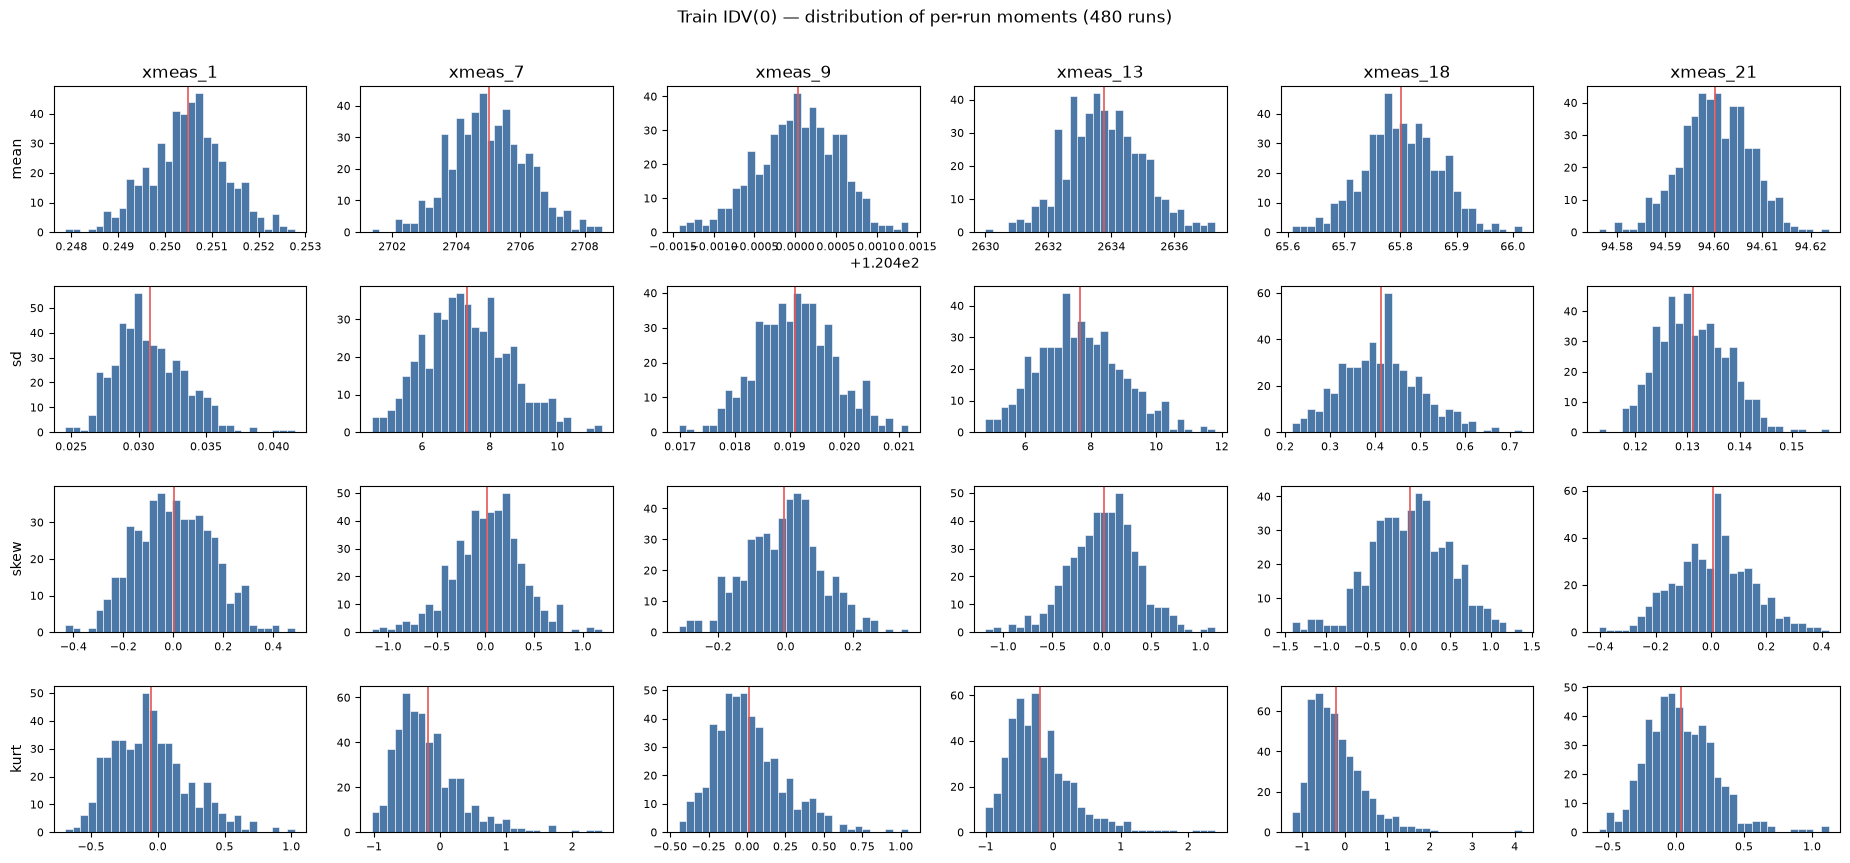

In [4]:
plot_sensors = [s for s in PLOT_SENSORS if s in SENSOR_COLS]
moment_keys = ("mean", "sd", "skew", "kurt")
fig, axes = plt.subplots(len(moment_keys), len(plot_sensors), figsize=(3.1 * len(plot_sensors), 8.5), sharey=False)
fig.suptitle("Train IDV(0) — distribution of per-run moments (480 runs)", y=1.01)

for j, sensor in enumerate(plot_sensors):
    for i, moment in enumerate(moment_keys):
        ax = axes[i, j]
        col = f"{sensor}__{moment}"
        vals = healthy_fit[col].to_numpy()
        ax.hist(vals, bins=30, color="#4C78A8", edgecolor="white", linewidth=0.4)
        ax.axvline(vals.mean(), color="#E45756", linewidth=1.2)
        if i == 0:
            ax.set_title(sensor)
        if j == 0:
            ax.set_ylabel(moment)
        ax.tick_params(labelsize=8)

fig.tight_layout()
plt.show()


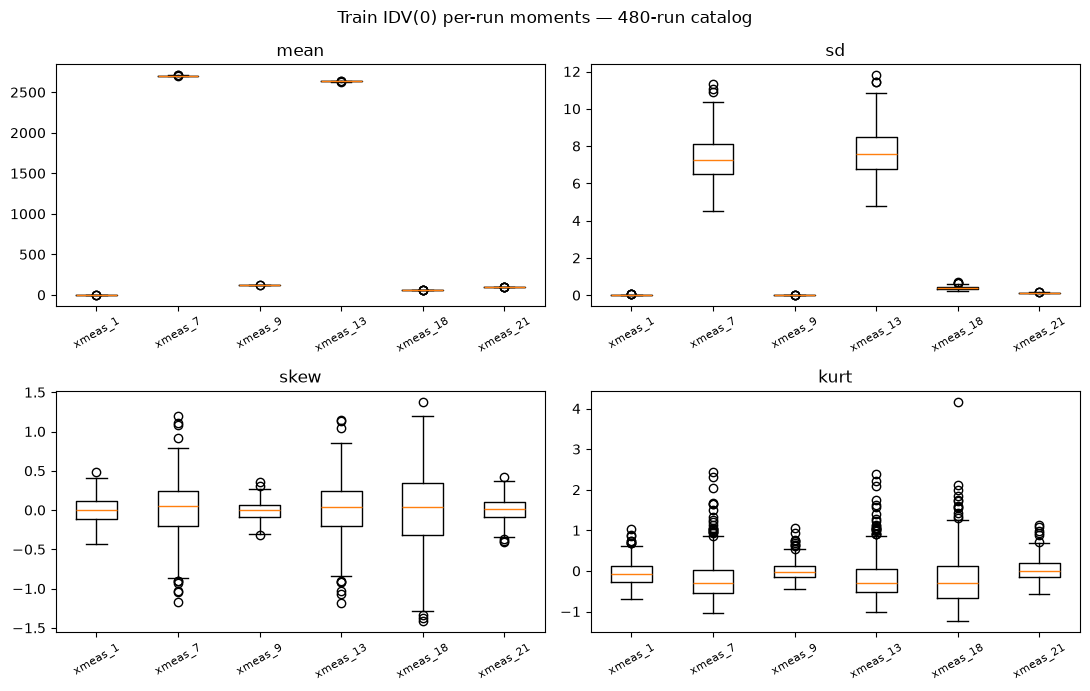

In [5]:
# Boxplots: how much each plotted sensor's four moments vary across the 480 healthy runs.
long_rows = []
for sensor in plot_sensors:
    for moment in moment_keys:
        col = f"{sensor}__{moment}"
        for v in healthy_fit[col].to_numpy():
            long_rows.append({"sensor": sensor, "moment": moment, "value": float(v)})
long_h = pd.DataFrame(long_rows)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle("Train IDV(0) per-run moments — 480-run catalog")
for ax, moment in zip(axes.ravel(), moment_keys):
    sub = long_h.loc[long_h["moment"].eq(moment)]
    data = [sub.loc[sub["sensor"].eq(s), "value"].to_numpy() for s in plot_sensors]
    ax.boxplot(data, tick_labels=plot_sensors, showfliers=True)
    ax.set_title(moment)
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
fig.tight_layout()
plt.show()


## 3. Score every run

Z-score the 208 moments with the healthy catalog (`μ`, `σ` from the 480 train IDV(0) runs only).

\[
\mathrm{error} = \frac{1}{208}\sum z_{s,m}^{2}
\]

That is a diagonal Mahalanobis distance. A run is predicted **faulty** if `error > μ_healthy + 3 σ_healthy` (also shown: 99th percentile of the fit scores).

- **Train error**: train faulty runs (TPR vs `fault_status`).
- **Test error**: test IDV(0) + test faulty (FPR and TPR vs `fault_status`).


In [6]:
Z = (moments[STAT_COLS] - mu) / sd
moments = moments.copy()
moments["error"] = Z.pow(2).mean(axis=1)
moments["max_abs_z"] = Z.abs().max(axis=1)

fit_errors = moments.loc[healthy_fit.index, "error"]
thr_3sd = float(fit_errors.mean() + RUN_SCORE_K_SD * fit_errors.std(ddof=0))
thr_p99 = float(np.percentile(fit_errors, THRESHOLD_PERCENTILE))
threshold = thr_3sd
moments["pred"] = moments["error"].gt(threshold).astype(np.int8)

kind = np.where(moments["faultNumber"].gt(0), "faulty", "normal")
moments["split"] = moments["source"].astype(str) + "_" + kind
fit_keys = set(zip(healthy_fit["simulationRun"].astype(int), healthy_fit["source"].astype(str)))
is_train_n = moments["source"].eq("train") & moments["faultNumber"].eq(0)
moments.loc[is_train_n, "split"] = [
    "train_normal_fit" if (int(run), str(src)) in fit_keys else "train_normal_hold"
    for run, src in zip(moments.loc[is_train_n, "simulationRun"], moments.loc[is_train_n, "source"])
]

log.info("threshold  mean+3sd=%.4f  p%.0f=%.4f  (using mean+3sd)", thr_3sd, THRESHOLD_PERCENTILE, thr_p99)
log.info("fit errors  mean=%.4f  sd=%.4f  n=%s", fit_errors.mean(), fit_errors.std(ddof=0), len(fit_errors))

score_summary = (
    moments.groupby("split")
    .agg(runs=("simulationRun", "size"), mean_error=("error", "mean"), median_error=("error", "median"), pred_rate=("pred", "mean"))
    .sort_index()
)
print("error by split")
display(score_summary.style.format({"mean_error": "{:.3f}", "median_error": "{:.3f}", "pred_rate": "{:.3f}"}))


13:37:19  INFO     threshold  mean+3sd=1.6658  p99=1.8772  (using mean+3sd)
13:37:19  INFO     fit errors  mean=1.0000  sd=0.2219  n=480


error by split


,runs,mean_error,median_error,pred_rate
split,,,,
test_faulty,10000,1614.055,110.569,0.799
test_normal,500,0.998,0.952,0.020
train_faulty,10000,3328.208,173.774,0.823
train_normal_fit,480,1.000,0.956,0.017
train_normal_hold,20,1.083,0.967,0.050


## 4. TPR / FPR vs `fault_status`

Label: `fault_status == "faulty"` (same as `faultNumber > 0` on this file). Prediction: the run error is above the healthy mean+3sd threshold.

| block | what it answers |
|---|---|
| **train faulty** | TPR on known train disturbances (train error) |
| **test** | TPR on test disturbances and FPR on test IDV(0) |

Row-level rates equal these run-level rates because every run has 500 samples and `fault_status` does not change inside a run.


In [7]:
def detection_table(frame: pd.DataFrame, y_col: str = "y_status") -> dict:
    y = frame[y_col].to_numpy(dtype=int)
    yhat = frame["pred"].to_numpy(dtype=int)
    tp = int(((y == 1) & (yhat == 1)).sum())
    fn = int(((y == 1) & (yhat == 0)).sum())
    fp = int(((y == 0) & (yhat == 1)).sum())
    tn = int(((y == 0) & (yhat == 0)).sum())
    tpr = tp / max(tp + fn, 1)
    fpr = fp / max(fp + tn, 1)
    return {
        "runs": int(len(frame)),
        "TPR": tpr,
        "FPR": fpr,
        "Youden": tpr - fpr,
        "TP": tp,
        "FN": fn,
        "FP": fp,
        "TN": tn,
        "mean_error": float(frame["error"].mean()),
    }


train_faulty = moments.loc[moments["split"].eq("train_faulty")]
test_all = moments.loc[moments["source"].eq("test")]
test_normal = moments.loc[moments["split"].eq("test_normal")]
test_faulty = moments.loc[moments["split"].eq("test_faulty")]

rows = {
    "train_faulty": detection_table(train_faulty),
    "test": detection_table(test_all),
    "test_normal (FPR only)": detection_table(test_normal),
    "test_faulty (TPR only)": detection_table(test_faulty),
    "train_normal_hold": detection_table(moments.loc[moments["split"].eq("train_normal_hold")]),
    "train_normal_fit (in-sample)": detection_table(moments.loc[moments["split"].eq("train_normal_fit")]),
}
rates = pd.DataFrame(rows).T
print(f"threshold = {threshold:.4f}  (healthy mean+{RUN_SCORE_K_SD:g} sd)")
print("labels = CSV fault_status  (faulty=1, normal=0)")
display(rates.style.format({"TPR": "{:.3f}", "FPR": "{:.3f}", "Youden": "{:.3f}", "mean_error": "{:.3f}", "runs": "{:.0f}", "TP": "{:.0f}", "FN": "{:.0f}", "FP": "{:.0f}", "TN": "{:.0f}"}))

assert (moments["y_run"] == moments["y_status"]).all(), "faultNumber and fault_status disagree"

by_idv = (
    moments.loc[moments["y_status"].eq(1)]
    .groupby(["source", "faultNumber"], observed=True)
    .agg(runs=("pred", "size"), TPR=("pred", "mean"), mean_error=("error", "mean"), median_error=("error", "median"))
)
print("\nTPR by source × IDV")
display(by_idv.style.format({"TPR": "{:.3f}", "mean_error": "{:.2f}", "median_error": "{:.2f}"}))


threshold = 1.6658  (healthy mean+3 sd)
labels = CSV fault_status  (faulty=1, normal=0)


,runs,TPR,FPR,Youden,TP,FN,FP,TN,mean_error
train_faulty,10000,0.823,0.000,0.823,8230,1770,0,0,3328.208
test,10500,0.799,0.020,0.779,7991,2009,10,490,1537.243
test_normal (FPR only),500,0.000,0.020,-0.020,0,0,10,490,0.998
test_faulty (TPR only),10000,0.799,0.000,0.799,7991,2009,0,0,1614.055
train_normal_hold,20,0.000,0.050,-0.050,0,0,1,19,1.083
train_normal_fit (in-sample),480,0.000,0.017,-0.017,0,0,8,472,1.000



TPR by source × IDV


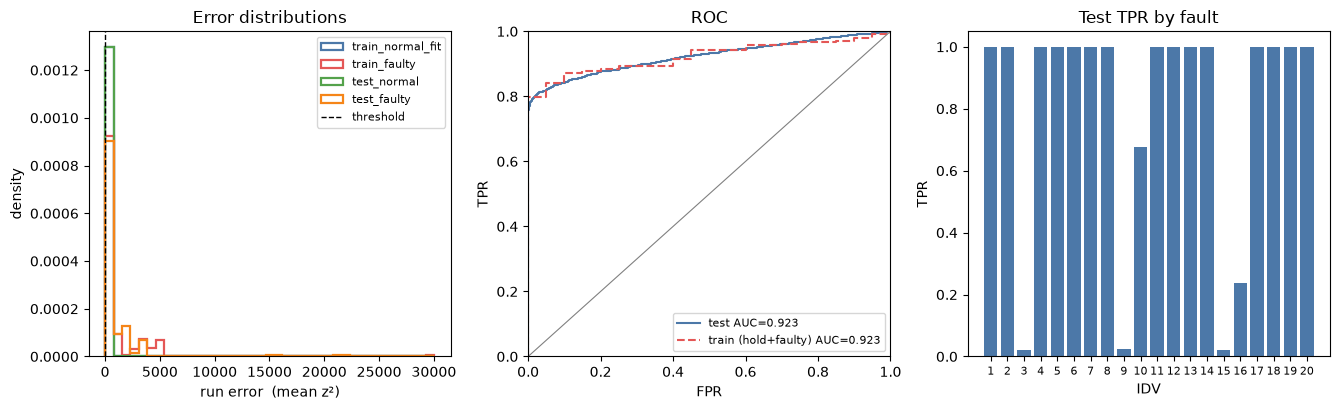

train faulty  TPR=82.3%  mean_error=3328.21
test          TPR=79.9%  FPR=2.0%  Youden=0.779


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

# score clouds
ax = axes[0]
bins = np.linspace(0, max(8.0, float(np.quantile(moments["error"], 0.98))), 40)
for split, color in (
    ("train_normal_fit", "#4C78A8"),
    ("train_faulty", "#E45756"),
    ("test_normal", "#54A24B"),
    ("test_faulty", "#F58518"),
):
    vals = moments.loc[moments["split"].eq(split), "error"]
    ax.hist(vals, bins=bins, histtype="step", density=True, linewidth=1.6, color=color, label=split)
ax.axvline(threshold, color="black", linestyle="--", linewidth=1, label="threshold")
ax.set_xlabel("run error  (mean z²)")
ax.set_ylabel("density")
ax.set_title("Error distributions")
ax.legend(fontsize=8)

# ROC on test (the set that has both classes)
ax = axes[1]
y_test = test_all["y_status"].to_numpy(dtype=int)
s_test = test_all["error"].to_numpy(dtype=float)
fpr_c, tpr_c, _ = roc_curve(y_test, s_test)
ax.plot(fpr_c, tpr_c, color="#4C78A8", label=f"test AUC={auc(fpr_c, tpr_c):.3f}")
y_tr = train_faulty["y_status"].to_numpy(dtype=int)
# train faulty has no negatives; ROC needs both classes — use train_normal_hold + train_faulty
train_roc = pd.concat([moments.loc[moments["split"].eq("train_normal_hold")], train_faulty], ignore_index=True)
fpr_tr, tpr_tr, _ = roc_curve(train_roc["y_status"], train_roc["error"])
ax.plot(fpr_tr, tpr_tr, color="#E45756", linestyle="--", label=f"train (hold+faulty) AUC={auc(fpr_tr, tpr_tr):.3f}")
ax.plot([0, 1], [0, 1], color="grey", linewidth=0.8)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC")
ax.legend(fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# TPR by IDV on test
ax = axes[2]
tpr_idv = (
    test_faulty.groupby("faultNumber")["pred"].mean().reindex(range(1, 21))
)
ax.bar(tpr_idv.index.astype(int), tpr_idv.to_numpy(), color="#4C78A8")
ax.set_xlabel("IDV")
ax.set_ylabel("TPR")
ax.set_title("Test TPR by fault")
ax.set_ylim(0, 1.05)
ax.set_xticks(range(1, 21))
ax.tick_params(axis="x", labelsize=8)

fig.tight_layout()
plt.show()

print(
    f"train faulty  TPR={rates.loc['train_faulty', 'TPR']:.1%}  mean_error={rates.loc['train_faulty', 'mean_error']:.2f}\n"
    f"test          TPR={rates.loc['test', 'TPR']:.1%}  FPR={rates.loc['test', 'FPR']:.1%}  "
    f"Youden={rates.loc['test', 'Youden']:.3f}"
)


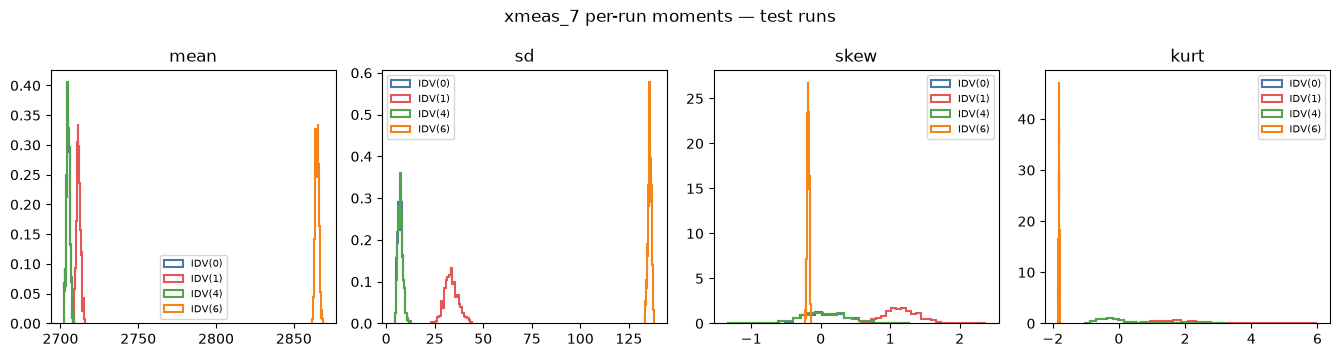

largest mean |z| lift  (test faulty − healthy catalog)


,delta_mean_abs_z
xmv_10__sd,99.25
xmv_3__mean,58.54
xmeas_21__sd,55.47
xmeas_23__mean,54.59
xmv_10__mean,53.25
xmv_6__mean,40.33
xmeas_22__sd,39.37
xmeas_1__mean,37.13
xmeas_10__mean,35.08
xmv_6__sd,34.81


In [9]:
# Healthy vs a few faults: same four moments, one sensor (xmeas_7 = reactor pressure).
# IDV(0) and IDV(4) sit on top of each other on this sensor — draw healthy last, dashed.
sensor = "xmeas_7" if "xmeas_7" in SENSOR_COLS else SENSOR_COLS[0]
compare = [
    (4, "#54A24B", "-", "IDV(4)"),
    (1, "#E45756", "-", "IDV(1)"),
    (6, "#F58518", "-", "IDV(6)"),
    (0, "#4C78A8", "--", "IDV(0)"),
]
src = "test"

fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.6))
fig.suptitle(f"{sensor} per-run moments — test runs  (IDV(0) dashed; it matches IDV(4) here)")
for ax, moment in zip(axes, moment_keys):
    col = f"{sensor}__{moment}"
    for fault, color, ls, label in compare:
        vals = moments.loc[moments["source"].eq(src) & moments["faultNumber"].eq(fault), col]
        ax.hist(vals, bins=25, histtype="step", density=True, linewidth=1.8, color=color, linestyle=ls, label=label)
    ax.set_title(moment)
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

healthy_mean_abs = Z.abs().loc[healthy_fit.index, STAT_COLS].mean()
test_fault_abs = Z.abs().loc[moments["split"].eq("test_faulty"), STAT_COLS].mean()
delta = (test_fault_abs - healthy_mean_abs).sort_values(ascending=False).head(15)
print("largest mean |z| lift  (test faulty − healthy catalog)")
display(delta.to_frame("delta_mean_abs_z").style.format("{:.2f}"))
